In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
import torch
sys.path.append('../../')

In [3]:
from neural_control.dynamics import SequentialDualSourcingModel, fractional_decoupling, binary_decoupling, straight_through_relu
from neural_control.demand_generators import FileBasedDemandGenerator
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import torch
from copy import deepcopy

import time
from plotly import graph_objects as go
torch.set_default_tensor_type(torch.cuda.FloatTensor)

In [4]:
service_type = 'low_service'

In [5]:
base_cofing = dict(h = 5, b = 495, cr = 0, ce = 20, lr = 2, le = 0)
service_configs = dict(high_service = dict(b=495), low_service = dict(b=95))

In [6]:
current_results = [
    dict(baselines='NNC', b=495, mean_cost=747117, median_cost=692118, method='current'),
    dict(baselines='CDI', b=495, mean_cost=773993, median_cost=770362, method='current'),
    dict(baselines='NNC', b=495, mean_cost=620968, median_cost=666600, method='future'),
    dict(baselines='CDI', b=495, mean_cost=722346, median_cost=716001, method='future'),    
    dict(baselines='NNC', b=95, mean_cost=583873, median_cost=563711, method='current'),
    dict(baselines='CDI', b=95, mean_cost=736018, median_cost=735265, method='current'),
    dict(baselines='NNC', b=95, mean_cost=564003, median_cost=541150, method='future'),
    dict(baselines='CDI', b=95, mean_cost=684495, median_cost=682958, method='future')
]
pd.DataFrame(current_results)

,baselines,b,mean_cost,median_cost,method
0,NNC,495,747117,692118,current
1,CDI,495,773993,770362,current
2,NNC,495,620968,666600,future
3,CDI,495,722346,716001,future
4,NNC,95,583873,563711,current
5,CDI,95,736018,735265,current
6,NNC,95,564003,541150,future
7,CDI,95,684495,682958,future


In [7]:
fbd = FileBasedDemandGenerator()

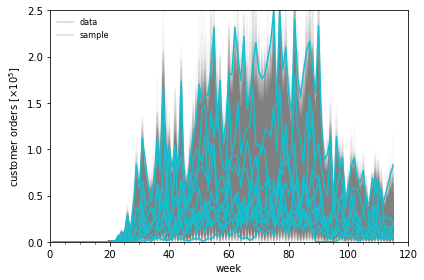

In [8]:
with np.errstate(divide='ignore', invalid='ignore'):
    #fbd.plot_gaussian_process_vs_model()
    #fbd.plot_distributions()
    fbd.plot_samples_vs_data()


In [9]:
sourcing_parameters = dict(T=fbd.max_weeks)
sourcing_parameters.update(base_cofing)
sourcing_parameters.update(service_configs[service_type])

In [10]:
class SimpleLSTMController(torch.nn.Module):
    def __init__(self,
                 n_input_features=3,
                 hidden_size=256,
                 proj_size=250,
                ):
        super().__init__()
        self.n_input_features = n_input_features
        self.input_layer = torch.nn.Linear(n_input_features, n_input_features)
        
        self.lstm_layer = torch.nn.LSTM(input_size=n_input_features, 
                                              hidden_size=hidden_size, 
                                              num_layers=1,
                                              batch_first=True,
                                              bidirectional=False,
                                              dropout=0.0,
                                              proj_size=proj_size
                                             )
        self.projection_skip_layer = torch.nn.Linear(n_input_features, proj_size)
        self.output_layer = torch.nn.Linear(proj_size, 4)
        
    def forward(self, x):
        x = torch.nn.functional.relu(self.input_layer(x))
        h, (h_T, c_T) =  self.lstm_layer(x)
        skip_h =  self.projection_skip_layer(x)
        y = self.output_layer(torch.relu(h+skip_h))
        y_int = fractional_decoupling(y[:, :, [0,1]])
        y_bin = binary_decoupling(y[:, :, [2,3]])
        y = straight_through_relu(y_int)*y_bin
        
        
        return y[:, : , 0], y[:, : , 1]       


In [11]:
N = 1 # aka minibatch size
T = fbd.max_weeks

sds = SequentialDualSourcingModel(**sourcing_parameters)
sds.I_0 = torch.tensor(0.0)


In [12]:
def validate_model(controller, val_N=512, test_T=T, dynamics=sds):
    with torch.no_grad():
        controller.eval()
        dynamics.reset(val_N)
        nn_input, initial_qr, initial_qe, initial_inventories, demands, past_demands = generate_state(N=val_N)

        new_qr, new_qe = controller(nn_input)

        qr = torch.cat([initial_qr, new_qr], dim=-1) if dynamics.lr > 0 else new_qr
        qe = torch.cat([initial_qe, new_qe], dim=-1) if dynamics.le > 0 else new_qe

        qe_arrived = qe[:, :test_T]
        qr_arrived = qr[:, :test_T]

        qe_ordered = qe[:, dynamics.le:]
        qr_ordered = qr[:, dynamics.lr:]

        costs, invs = dynamics.replay_multisteps(initial_inventories, 
                                                        qra=qr_arrived,
                                                        qea=qe_arrived,
                                                        qro=qr_ordered,
                                                        qeo=qe_ordered,
                                                        all_demands=demands
                                                       )
        mean_costs = costs.mean().item()
        median_costs = costs.median().item()
        
        return (mean_costs, 
                median_costs, 
                qr.cpu().detach().numpy(),
                qe.cpu().detach().numpy(), 
                invs.cpu().detach().numpy(),
                demands.cpu().detach().numpy(), 
                initial_inventories.cpu().detach().numpy()
               )
    

In [13]:
std_vector = torch.tensor(fbd.std_array).float()
mean_vector = torch.tensor(fbd.mean_array).float()
def generate_state(N=16, T=T, use_mean=False, use_std=False, mean_shift=1, std_shift=1):
    sds.reset(N)
    inital_inventories = torch.randint(low=0, high=100 + 1, size=(N,1) ).float()#sds.I_0.repeat(N, 1)
    initial_demands = sds.all_demands[0]
    initial_qr = torch.cat(sds.previous_qr, dim=-1)
    initial_qe = torch.cat(sds.previous_qe, dim=-1)
    future_demands = fbd.sample_trajectory(t=0, n_samples=N, n_timesteps=T)
    demands = torch.cat([initial_demands, future_demands], dim=-1).float()
    past_demands = demands[:, :-1]
    nn_input = (inital_inventories - past_demands).unsqueeze(-1) #(inital_inventories - past_demands).diff(dim=1, prepend=torch.zeros(N, 1)).unsqueeze(-1)
    
    nn_input_2 = torch.zeros_like(mean_vector.unsqueeze(0).unsqueeze(-1).repeat(N,1,1))
    nn_input_3 = torch.zeros_like(std_vector.unsqueeze(0).unsqueeze(-1).repeat(N,1,1))
    
    if use_mean:
        nn_input_2 = mean_vector.unsqueeze(0).unsqueeze(-1).roll(mean_shift, dims=1)
        if mean_shift > 0:
            nn_input_2[:, :mean_shift, :] = 0
        if mean_shift < 0:
            nn_input_2[:, mean_shift:, :] = 0        
        nn_input_2 = nn_input_2.repeat(N,1,1)
        
    if use_std:
        nn_input_3 = std_vector.unsqueeze(0).unsqueeze(-1).roll(std_shift, dims=1)
        if std_shift > 0:
            nn_input_3[:, :std_shift, :] = 0
        if std_shift < 0:
            nn_input_3[:, std_shift:, :] = 0        
        nn_input_3 = nn_input_3.repeat(N,1,1)
        
    nn_input = torch.cat([nn_input, 
                          nn_input_2,
                          nn_input_3
                         ], dim=-1)
    return nn_input, initial_qr, initial_qe, inital_inventories, demands, past_demands

In [33]:
sc = SimpleLSTMController()

In [34]:
optimizer = torch.optim.RMSprop(sc.parameters(), lr=1e-3)
for i in range(10):
    nn_input, initial_qr, initial_qe, inital_inventories, demands, past_demands = generate_state()
    optimizer.zero_grad()
    new_qr, new_qe = sc(nn_input)
    new_qr = new_qr.roll(sourcing_parameters['lr'], dims=1)
    new_qr[:, :sourcing_parameters['lr']] = 0*new_qr[:, :sourcing_parameters['lr']]
    
    new_qe = new_qe.roll(sourcing_parameters['le'], dims=1)
    new_qe[:, :sourcing_parameters['le']] = 0*new_qe[:, :sourcing_parameters['le']]
    
    loss = ((new_qr - (past_demands-new_qe.detach()))**2).mean() + ((new_qe - (past_demands-new_qr.detach()))**2).mean()*0.001
    loss.backward()
    optimizer.step()
new_qr, new_qe = sc(nn_input)
new_qr

tensor([[4.4000e+01, 4.4000e+01, 4.6000e+01,  ..., 6.1460e+03, 1.2405e+04,
         1.2203e+04],
        [6.5000e+01, 6.6000e+01, 6.6000e+01,  ..., 1.0930e+04, 9.9140e+03,
         1.3929e+04],
        [3.0000e+00, 3.0000e+00, 4.0000e+00,  ..., 9.3370e+03, 4.9250e+03,
         1.7276e+04],
        ...,
        [6.7000e+01, 6.7000e+01, 6.8000e+01,  ..., 2.2220e+03, 1.2802e+04,
         1.0422e+04],
        [4.2000e+01, 4.2000e+01, 4.3000e+01,  ..., 1.5610e+03, 1.0380e+04,
         1.1020e+04],
        [3.0000e+00, 3.0000e+00, 4.0000e+00,  ..., 9.6150e+03, 3.3490e+03,
         3.3530e+03]], grad_fn=<SelectBackward0>)

In [35]:
new_qe

tensor([[0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 5.7800e+03, 1.1669e+04,
         1.1479e+04],
        [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 1.0281e+04, 9.3250e+03,
         1.3103e+04],
        [0.0000e+00, 0.0000e+00, 3.0000e+00,  ..., 8.7820e+03, 4.6310e+03,
         1.6252e+04],
        ...,
        [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 2.0880e+03, 1.2042e+04,
         9.8030e+03],
        [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 1.4660e+03, 9.7640e+03,
         1.0366e+04],
        [0.0000e+00, 0.0000e+00, 3.0000e+00,  ..., 9.0440e+03, 3.1480e+03,
         3.1510e+03]], grad_fn=<SelectBackward0>)

In [36]:
training_costs = []
val_costs = []
best_val_loss = [np.infty]
best_model = [deepcopy(sc.state_dict())]
fig = go.FigureWidget()
fig.add_scatter()
fig.add_scatter()
fig

FigureWidget({
    'data': [{'type': 'scatter', 'uid': '506ed1e2-d727-4304-9565-a0397adc0c1a'},
             {…

In [37]:
nn_input, initial_qr, initial_qe, inital_inventories, demands, past_demands = generate_state(N=128)
optimizer = torch.optim.RMSprop(sc.parameters(), lr=1e-3)
for i in range(50000):
    sc.train()
    optimizer.zero_grad()
    new_qr, new_qe = sc(nn_input)

    qr = torch.cat([initial_qr, new_qr], dim=-1) if sds.lr > 0 else new_qr
    qe = torch.cat([initial_qe, new_qe], dim=-1) if sds.le > 0 else new_qe

    qe_arrived = qe[:, :T]
    qr_arrived = qr[:, :T]

    qe_ordered = qe[:, sds.le:]
    qr_ordered = qr[:, sds.lr:]

    costs, invs = sds.replay_multisteps(inital_inventories, 
                                        qra=qr_arrived,
                                        qea=qe_arrived,
                                        qro=qr_ordered,
                                        qeo=qe_ordered,
                                        all_demands=demands
                                        )
    J = (costs[costs > costs.quantile(0.3, dim=0, keepdim=True)]).mean()# + (0.5*costs.max(dim=0).values).mean()
    J.backward()
    optimizer.step()
    training_costs.append(costs.mean().item())
    val_cost, _, _, _, _, _, _ = validate_model(sc)
    val_costs.append(val_cost)
    
    if val_cost < best_val_loss[0]:
        best_val_loss[0] = val_cost
        best_model[0] = deepcopy(sc.state_dict())
    elif not np.isfinite(val_cost):
        sc.load_state_dict(best_model[0])
    
    if i%1000 == 0 and i > 3000:
        lr = 1e-3
        optimizer = torch.optim.RMSprop(sc.parameters(), lr=lr)
        nn_input, initial_qr, initial_qe, inital_inventories, demands, past_demands = generate_state(N=16)
        if  np.mean(val_costs[-5:]) > 2*best_val_loss[0]:
            sc.load_state_dict(best_model[0])

        print(costs.mean())
    if i%100 == 0: 
        time.sleep(0.01)
        with fig.batch_update():
            fig.data[0].y = training_costs
            fig.data[1].y = val_costs

tensor(829191.8125, grad_fn=<MeanBackward0>)
tensor(869025.8125, grad_fn=<MeanBackward0>)
tensor(813398.6875, grad_fn=<MeanBackward0>)
tensor(805888.8750, grad_fn=<MeanBackward0>)
tensor(2058950.2500, grad_fn=<MeanBackward0>)
tensor(816959.9375, grad_fn=<MeanBackward0>)
tensor(1844809.1250, grad_fn=<MeanBackward0>)
tensor(822979.8750, grad_fn=<MeanBackward0>)
tensor(1546399.8750, grad_fn=<MeanBackward0>)
tensor(1249330.2500, grad_fn=<MeanBackward0>)
tensor(1424728.3750, grad_fn=<MeanBackward0>)
tensor(1315460.3750, grad_fn=<MeanBackward0>)
tensor(1049388.3750, grad_fn=<MeanBackward0>)
tensor(1125017.2500, grad_fn=<MeanBackward0>)
tensor(1055255.3750, grad_fn=<MeanBackward0>)
tensor(993046.4375, grad_fn=<MeanBackward0>)
tensor(1076213.1250, grad_fn=<MeanBackward0>)
tensor(930453.2500, grad_fn=<MeanBackward0>)
tensor(977563.6875, grad_fn=<MeanBackward0>)
tensor(1375791.7500, grad_fn=<MeanBackward0>)
tensor(1332193.8750, grad_fn=<MeanBackward0>)


KeyboardInterrupt: 

In [38]:
sc.load_state_dict(best_model[0])

<All keys matched successfully>

In [39]:
test_cost, test_median_cost, new_qr, new_qe, invs, demands, I_0 = validate_model(sc, val_N=2096)

In [42]:
test_cost

794316.4375

In [43]:
test_median_cost

650219.375

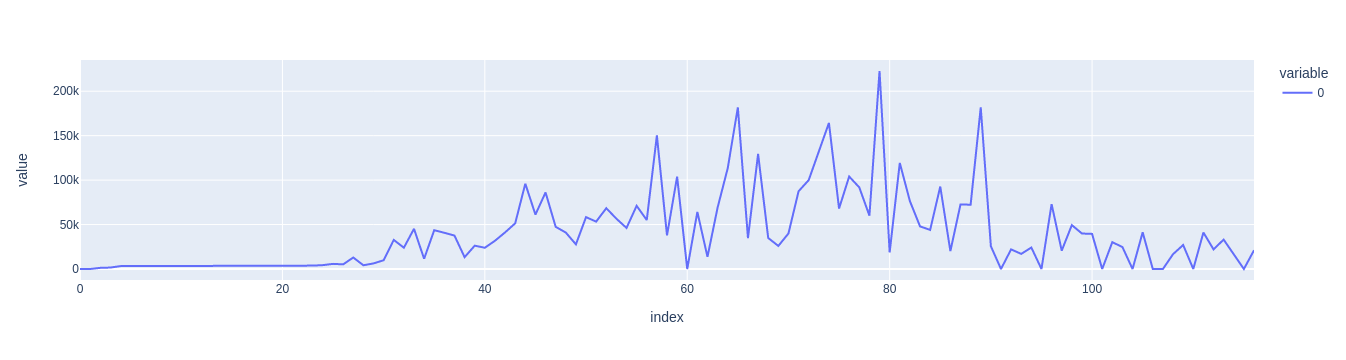

In [44]:
import plotly.express as px
px.line(new_qr[0, :])

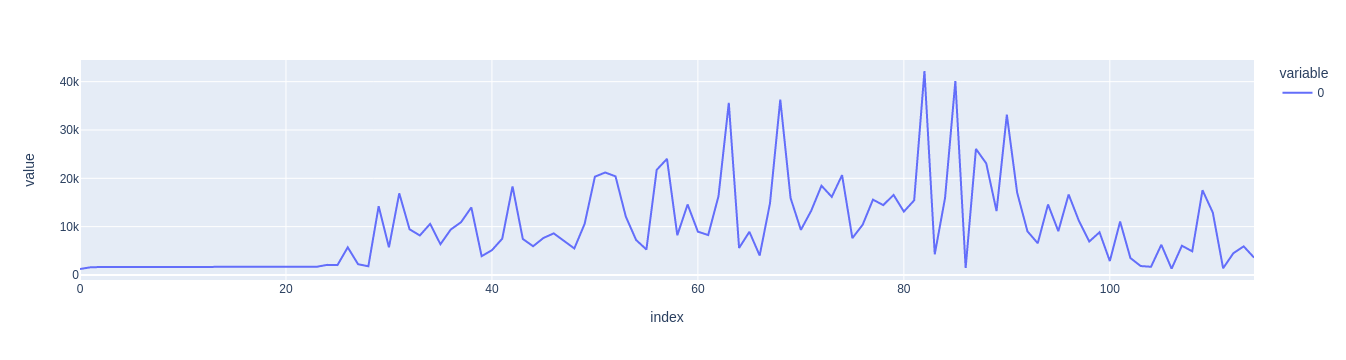

In [24]:
px.line(new_qe[0, :])

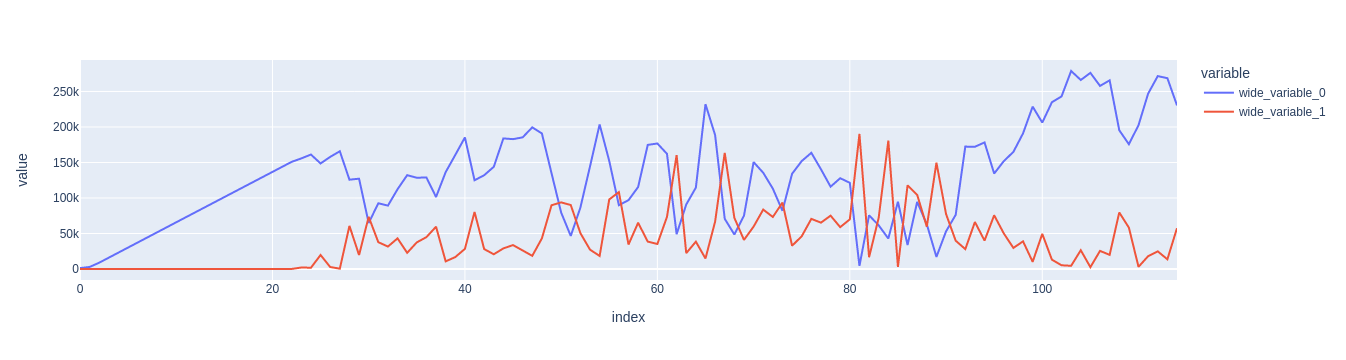

In [25]:
px.line(y=[invs[0, :], demands[0, 1:]])

In [ ]:
demands[0]